<a href="https://colab.research.google.com/github/aab314/Week_4_Giardino/blob/main/Lab8_WinstonLutz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MP-566 Lab 8 — Winston-Lutz Test

Use [**pylinac**](https://pylinac.readthedocs.io/en/latest/winston_lutz.html) to check whether the TrueBeam's **mechanical** and **radiation** isocenters coincide within TG-142 / TG-198 tolerance.

**What you'll produce**
- Table of per-image 2D shifts (`Δu`, `Δv`, total).
- 3D shift vector from the radiation isocenter to the BB.
- Several pylinac-generated figures (per-image overlays, axis-grouped views, 3D isocenter visualization, summary plot).

Cells labeled **`TODO`** are for you to fill in. Each has a hint.

## 1. Install pylinac

In [3]:
!pip install --quiet pylinac pandas pydicom
import warnings
warnings.filterwarnings("ignore")

## 2. Upload the DICOMs

Run the cell below and use the file picker to select all **14 `.dcm` files** (one per Winston-Lutz field in Table 1 of the handout). They will be copied into a `Lab_Data_Final/` folder next to the notebook.

> Tip: in the Colab upload dialog you can Ctrl/Cmd-click or Shift-click to select all 14 files at once.

In [4]:
import os, glob, shutil

DATA_DIR = "Lab_Data_Final"
os.makedirs(DATA_DIR, exist_ok=True)

# If the folder doesn't already have the 14 DICOMs, prompt an upload (Colab only)
if len(glob.glob(os.path.join(DATA_DIR, "*.dcm"))) < 14:
    try:
        from google.colab import files
        print("Please select all 14 .dcm files in the picker ...")
        uploaded = files.upload()
        for fname in uploaded:
            shutil.move(fname, os.path.join(DATA_DIR, fname))
    except ImportError:
        raise FileNotFoundError(
            f"Not on Colab. Place the 14 .dcm files inside '{DATA_DIR}/' next to this notebook."
        )

# Sanity check
n = len(glob.glob(os.path.join(DATA_DIR, "*.dcm")))
print(f"Found {n} DICOM files in '{DATA_DIR}/'")
assert n == 14, f"Expected 14 WL images, got {n}."

Please select all 14 .dcm files in the picker ...


Saving RI.1.2.246.352.62.1.4676876179822890130.7166830823224182672.dcm to RI.1.2.246.352.62.1.4676876179822890130.7166830823224182672.dcm
Saving RI.1.2.246.352.62.1.4737144539073454676.5929635556220200084.dcm to RI.1.2.246.352.62.1.4737144539073454676.5929635556220200084.dcm
Saving RI.1.2.246.352.62.1.5004602547499327627.16651696065357578903.dcm to RI.1.2.246.352.62.1.5004602547499327627.16651696065357578903.dcm
Saving RI.1.2.246.352.62.1.5061817036199084325.18167131020672989351.dcm to RI.1.2.246.352.62.1.5061817036199084325.18167131020672989351.dcm
Saving RI.1.2.246.352.62.1.5095582538180588125.14004467983293187759.dcm to RI.1.2.246.352.62.1.5095582538180588125.14004467983293187759.dcm
Saving RI.1.2.246.352.62.1.5128857494559911644.7629199487068709796.dcm to RI.1.2.246.352.62.1.5128857494559911644.7629199487068709796.dcm
Saving RI.1.2.246.352.62.1.5281095142730180765.3833956500776492706.dcm to RI.1.2.246.352.62.1.5281095142730180765.3833956500776492706.dcm
Saving RI.1.2.246.352.62.1.5

## 3. Meet your DICOM files

**DICOM** (Digital Imaging and Communications in Medicine) is the standard file format in radiology and radiation oncology. Every DICOM file contains two things:

1. A **pixel array** (the actual image/radiation data).
2. A **header** of tagged metadata: patient info, machine parameters, beam geometry, acquisition time, etc.

Each tag is identified by a `(group, element)` number and a human-readable keyword (e.g., `(0018, 1110)` = `"RTImageSID"`). Python's [`pydicom`](https://pydicom.github.io/) library lets you read both in one line.

For the Winston-Lutz analysis, the tags that matter are:

| DICOM keyword | What it is | Why we care |
|---|---|---|
| `GantryAngle` | Gantry rotation (°) | Which direction the beam came from |
| `BeamLimitingDeviceAngle` | Collimator angle (°) | Record only |
| `PatientSupportAngle` | Couch rotation (°) | Couch-kick fields (13 & 14) |
| `ImagePlanePixelSpacing` | Detector pixel pitch (mm) | Convert pixels → mm |
| `RTImageSID` / `RadiationMachineSAD` | Source-to-imager / source-to-axis distance (mm) | Magnification: a shift on the imager divided by SID/SAD gives the shift at isocenter |

The cell below lists your 14 files and shows the header of the first one.

In [5]:
import pydicom

dcm_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.dcm")))
print(f"{len(dcm_files)} DICOM files:")
for f in dcm_files:
    print(" ", os.path.basename(f))

# Peek at the first file
d = pydicom.dcmread(dcm_files[0])
print("\n--- Header of the first image ---")
print(f"Modality              : {d.Modality}")
print(f"Manufacturer          : {d.Manufacturer}")
print(f"Radiation type        : {getattr(d, 'RTImageLabel', 'n/a')}")
print(f"Gantry angle [deg]    : {d.GantryAngle:.2f}")
print(f"Collimator angle [deg]: {d.BeamLimitingDeviceAngle:.2f}")
print(f"Couch angle [deg]     : {d.PatientSupportAngle:.2f}")
print(f"Pixel spacing [mm]    : {list(d.ImagePlanePixelSpacing)}")
print(f"SID / SAD [mm]        : {d.RTImageSID:.1f} / {d.RadiationMachineSAD}")
print(f"Magnification (SID/SAD): {d.RTImageSID/d.RadiationMachineSAD:.3f}")
print(f"Image shape (pixels)  : {d.pixel_array.shape}")
print(f"Pixel value range     : {d.pixel_array.min()} – {d.pixel_array.max()}")

14 DICOM files:
  RI.1.2.246.352.62.1.4676876179822890130.7166830823224182672.dcm
  RI.1.2.246.352.62.1.4737144539073454676.5929635556220200084.dcm
  RI.1.2.246.352.62.1.5004602547499327627.16651696065357578903.dcm
  RI.1.2.246.352.62.1.5061817036199084325.18167131020672989351.dcm
  RI.1.2.246.352.62.1.5095582538180588125.14004467983293187759.dcm
  RI.1.2.246.352.62.1.5128857494559911644.7629199487068709796.dcm
  RI.1.2.246.352.62.1.5281095142730180765.3833956500776492706.dcm
  RI.1.2.246.352.62.1.5368208858195086521.10757115171572789925.dcm
  RI.1.2.246.352.62.1.5395624370889904065.14400374232720504199.dcm
  RI.1.2.246.352.62.1.5431217922439912276.15815255458350917774.dcm
  RI.1.2.246.352.62.1.5502645452551769323.15239496395426771842.dcm
  RI.1.2.246.352.62.1.5520824783793774322.8657616163614841475.dcm
  RI.1.2.246.352.62.1.5596971782049973177.4442633469053608633.dcm
  RI.1.2.246.352.62.1.5727706079567487575.5105286893333396382.dcm

--- Header of the first image ---
Modality          

### Inventory of all 14 fields

Let's cross-check against **Table 1** of the handout (the planned gantry / collimator / couch combinations). We'll pull the angles out of every DICOM and display them as a pandas table.

Note that 360.0 deg = 0.0 deg.

In [6]:
import pandas as pd

def _clean(angle):
    """Round to 0.1 deg and wrap 360 -> 0 so the table matches Table 1."""
    a = round(angle, 1)
    return 0.0 if a == 360.0 else a

rows = []
for f in dcm_files:
    h = pydicom.dcmread(f, stop_before_pixels=True)
    rows.append({
        "file":       os.path.basename(f),
        "gantry":     _clean(h.GantryAngle),
        "collimator": _clean(h.BeamLimitingDeviceAngle),
        "couch":      _clean(h.PatientSupportAngle),
    })
pd.DataFrame(rows)

,file,gantry,collimator,couch
0,RI.1.2.246.352.62.1.4676876179822890130.716683...,0.0,0.0,90.0
1,RI.1.2.246.352.62.1.4737144539073454676.592963...,270.0,270.0,0.0
2,RI.1.2.246.352.62.1.5004602547499327627.166516...,0.0,0.0,0.0
3,RI.1.2.246.352.62.1.5061817036199084325.181671...,270.0,90.0,0.0
4,RI.1.2.246.352.62.1.5095582538180588125.140044...,0.0,270.0,0.0
5,RI.1.2.246.352.62.1.5128857494559911644.762919...,180.0,90.0,0.0
6,RI.1.2.246.352.62.1.5281095142730180765.383395...,90.0,90.0,0.0
7,RI.1.2.246.352.62.1.5368208858195086521.107571...,90.0,0.0,0.0
8,RI.1.2.246.352.62.1.5395624370889904065.144003...,270.0,0.0,0.0
9,RI.1.2.246.352.62.1.5431217922439912276.158152...,0.0,0.0,270.0


### Look at the raw image

A WL portal image is very simple: a **bright disk** (the 20 mm cone-collimated field) with a **small dark spot** in the middle (the tungsten BB absorbing the MV photons). Our whole job is to locate both centroids and measure the offset between them.

The cell below plots the first DICOM's pixel array. Try changing `IDX` to see different fields and notice that:

- The bright disk stays roughly centered on the EPID.
- The BB shifts by a fraction of a pixel as the gantry rotates — that tiny wobble is what we're after.

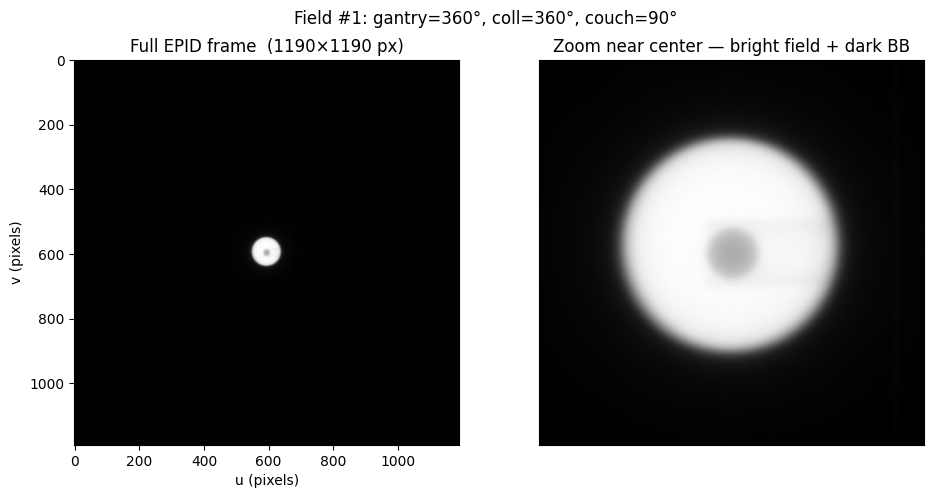

In [7]:
import matplotlib.pyplot as plt

IDX = 0                      # change to 0..13 to explore

d   = pydicom.dcmread(dcm_files[IDX])
img = d.pixel_array

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
ax1.imshow(img, cmap="gray")
ax1.set_title(f"Full EPID frame  ({img.shape[0]}×{img.shape[1]} px)")
ax1.set_xlabel("u (pixels)"); ax1.set_ylabel("v (pixels)")

cy, cx = img.shape[0] // 2, img.shape[1] // 2
half = 80
ax2.imshow(img[cy-half:cy+half, cx-half:cx+half], cmap="gray")
ax2.set_title("Zoom near center — bright field + dark BB")
ax2.set_xticks([]); ax2.set_yticks([])

fig.suptitle(f"Field #{IDX+1}: gantry={d.GantryAngle:.0f}°, "
             f"coll={d.BeamLimitingDeviceAngle:.0f}°, couch={d.PatientSupportAngle:.0f}°")
plt.show()

## 4. Run the Winston-Lutz analysis

Pylinac segments the radiation field and the BB on every image and solves for the 3D offset between the radiation isocenter and the BB using the Low *et al.* (1995) formalism.

### 🔧 TODO #1 — set the BB size

Our phantom uses a small tungsten sphere. Look at the lab handout / Winston-Lutz tool and set its diameter in millimeters.

In [9]:
from pylinac import WinstonLutz

BB_SIZE_MM = 5 #...      # TODO #1: BB diameter in mm

wl = WinstonLutz(DATA_DIR)
wl.analyze(bb_size_mm=BB_SIZE_MM)
print(f"Analyzed {len(wl.images)} images.")

Analyzed 14 images.


## 5. Per-image 2D shifts (`Δu`, `Δv`, total)

`u` and `v` are the in-plane axes of the MV portal image (see **Figure 1** of the lab handout) — the horizontal and vertical directions on the EPID, expressed in mm at the isocenter plane. Pylinac doesn't use the `u`/`v` names; it just calls them `.x` and `.y` on the returned vector:

```python
img.cax2bb_vector.x   # horizontal shift on the imager  →  Δu
img.cax2bb_vector.y   # vertical   shift on the imager  →  Δv
img.cax2bb_distance   # sqrt(Δu² + Δv²), the total 2D shift
```

The sign convention is arbitrary (pylinac's `.y` is inverted compared to raw pixel coordinates), but the magnitude is what TG-142 cares about.

### 🔧 TODO #2 — complete the loop

Fill `du`, `dv`, and `total` using those attributes.

> **Hint:** `shift = img.cax2bb_vector` gives you `shift.x` and `shift.y`. For the total, use `img.cax2bb_distance`.

In [12]:
print(f"{'#':>3} {'Gantry':>7} {'Coll':>6} {'Couch':>6} "
      f"{'du [mm]':>10} {'dv [mm]':>10} {'Total [mm]':>12}")
print("-" * 60)
for i, img in enumerate(wl.images, start=1):
    shift = img.cax2bb_vector       # 2D vector in the imager plane (mm at iso)
    #print(shift.x)

    du    = shift.x    # TODO #2: horizontal shift on the EPID
    dv    = shift.y     # TODO #2: vertical   shift on the EPID
    total = img.cax2bb_distance     # TODO #2: total 2D shift magnitude

    print(f"{i:>3} {img.gantry_angle:>7.1f} {img.collimator_angle:>6.1f} "
          f"{img.couch_angle:>6.1f} {du:>+10.4f} {dv:>+10.4f} {total:>12.4f}")

  #  Gantry   Coll  Couch    du [mm]    dv [mm]   Total [mm]
------------------------------------------------------------
  1     0.0   90.0    0.0    +0.4120    +0.0561       0.4158
  2     0.0  270.0    0.0    -0.5556    +0.5523       0.7834
  3     0.0  360.0    0.0    +0.1955    +0.8013       0.8249
  4    90.0   90.0    0.0    +0.7216    -0.1959       0.7477
  5    90.0  270.0    0.0    -0.2405    +0.3067       0.3898
  6    90.0  360.0    0.0    +0.4901    +0.5365       0.7266
  7   180.0    0.0    0.0    +0.2044    +0.2678       0.3369
  8   180.0   90.0    0.0    +0.4010    -0.4756       0.6221
  9   180.0  270.0    0.0    -0.5416    +0.0207       0.5420
 10   270.0    0.0    0.0    -0.1050    +0.4762       0.4876
 11   270.0   90.0    0.0    +0.0945    -0.2790       0.2946
 12   270.0  270.0    0.0    -0.8649    +0.2325       0.8956
 13   360.0  360.0   90.0    +0.2984    +0.8363       0.8879
 14   360.0  360.0  270.0    +0.2457    +0.7034       0.7451


## 6. The 3D shift vector

A single image only sees the shift **projected onto the imager plane** — the component along the beam is invisible. Imaging the BB from many angles lets pylinac solve for the 3D offset between the radiation isocenter and the BB (`wl.bb_shift_vector`).

### 🔧 TODO #3 — compute the magnitude

Fill in the Euclidean length of the 3D vector.

> **Hint:** $|\vec{s}| = \sqrt{s_x^2 + s_y^2 + s_z^2}$

In [15]:
s = wl.bb_shift_vector

#print(s.x)

import math
magnitude = (s.x**2 + s.y**2 + s.z**2)**.5    # TODO #3

print(f"X: {s.x:+.4f} mm")
print(f"Y: {s.y:+.4f} mm")
print(f"Z: {s.z:+.4f} mm")
print(f"|3D|: {magnitude:.4f} mm")
print()
print(wl.bb_shift_instructions())      # which way to push the couch to fix it

X: +0.0181 mm
Y: +0.1680 mm
Z: +0.3078 mm
|3D|: 0.3511 mm

RIGHT 0.02mm; IN 0.17mm; UP 0.31mm


## 7. Pylinac plots 🎨

Pylinac ships with several built-in visualizations. Run the cells below.

### 7a. Single image — field CAX (green) vs. BB (red)

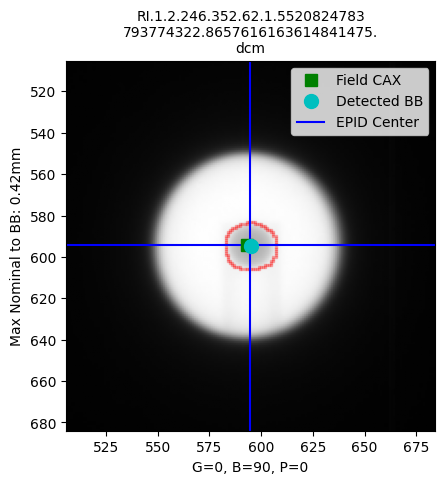

<Axes: title={'center': 'RI.1.2.246.352.62.1.5520824783\n793774322.8657616163614841475.\ndcm'}, xlabel='G=0, B=90, P=0', ylabel='Max Nominal to BB: 0.42mm'>

In [16]:
IMG_INDEX = 0                      # try changing to 0..13
wl.images[IMG_INDEX].plot()

### 7b. All 14 fields at once

By default `plot_images()` only shows gantry-only fields (collimator = couch = 0). Since our plan mixes gantry, collimator, and couch rotations, we pass `axis=Axis.GBP_COMBO` to force *every* image into the grid.


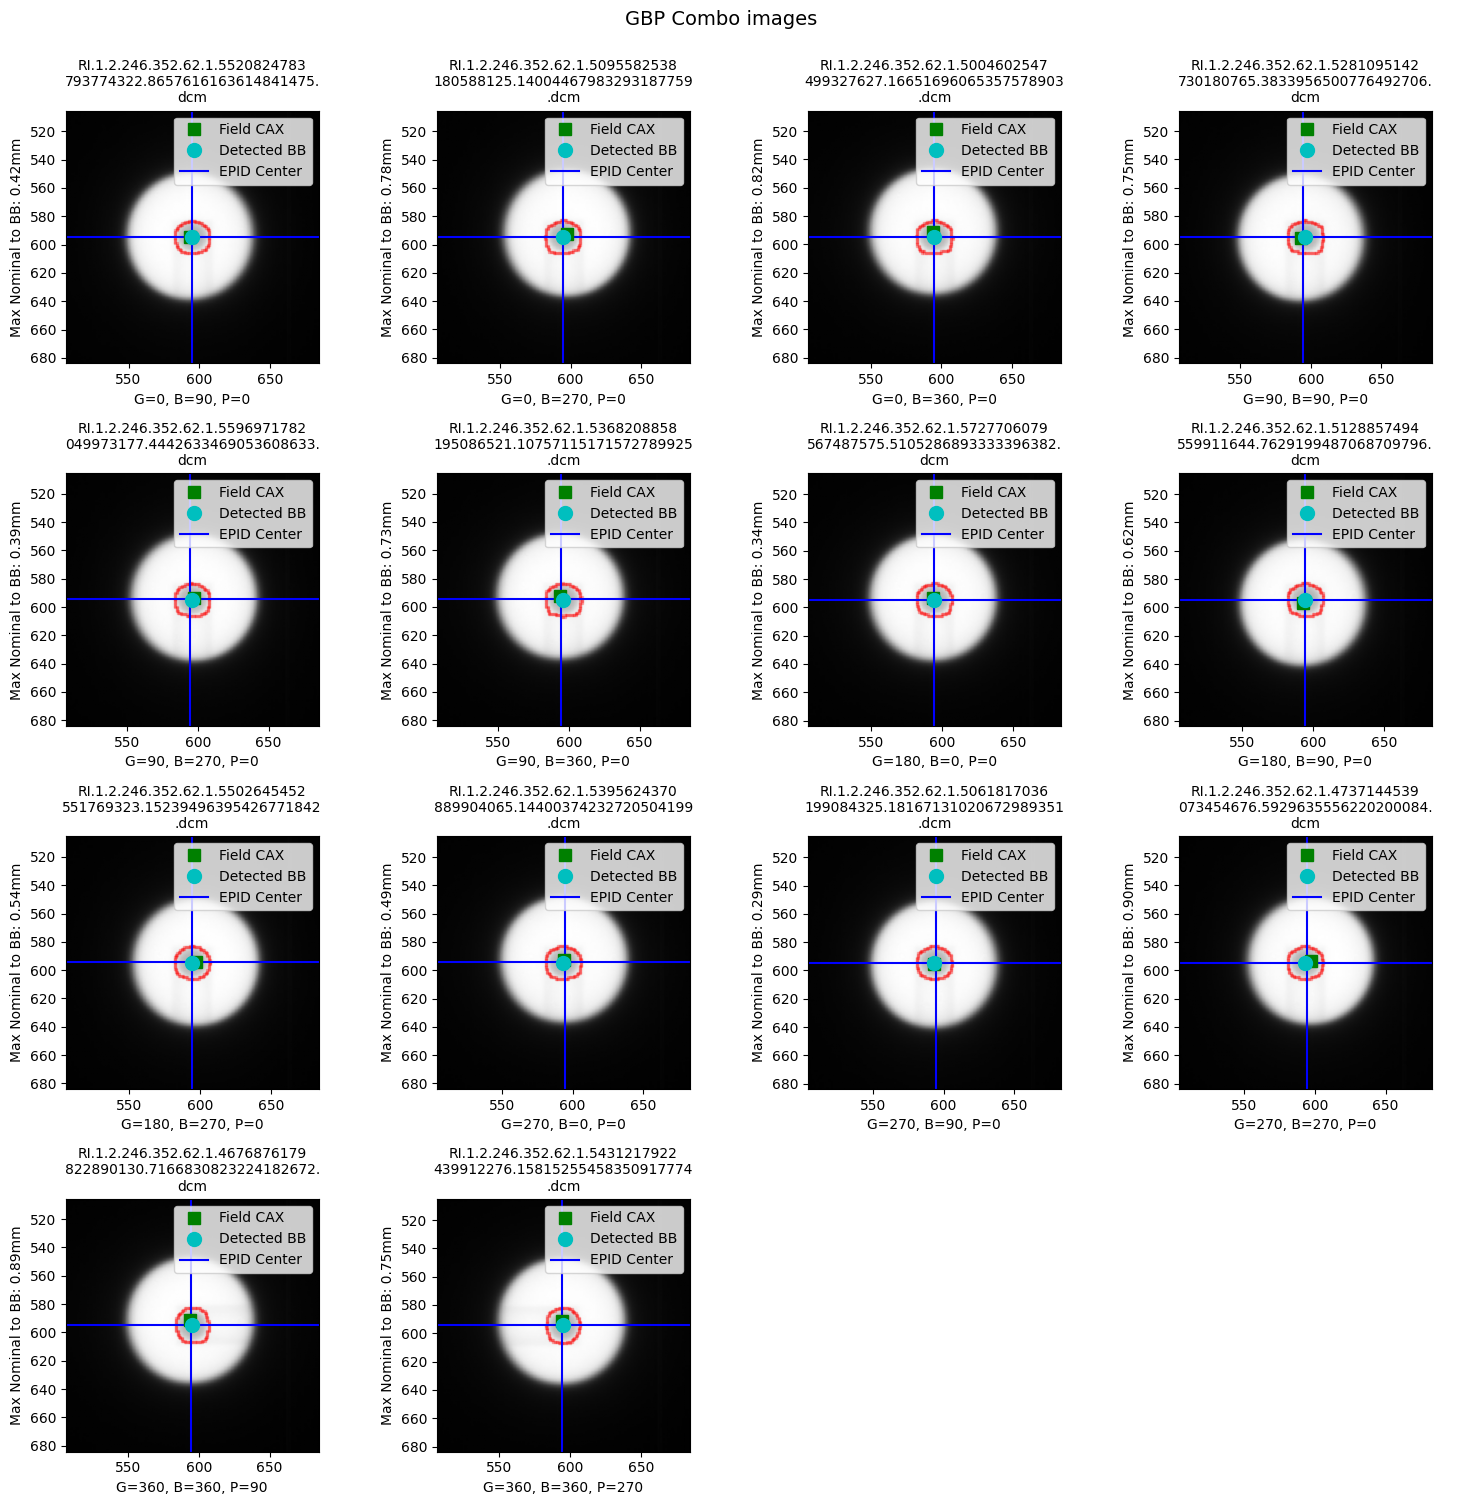

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


([<Figure size 1500x1500 with 16 Axes>], ['image'])

In [17]:
from pylinac.winston_lutz import Axis
wl.plot_images(axis=Axis.GBP_COMBO)

### 7c. Axis-grouped view (gantry / collimator / couch)

`plot_axis_images(axis=...)` shows only the images where that single axis was rotated (the others held at 0). Useful for seeing which axis contributes most to the isocenter wobble.

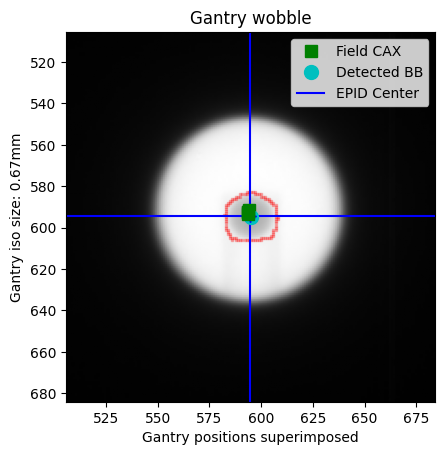

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


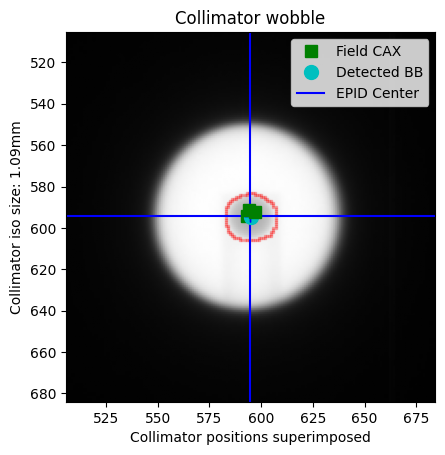

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


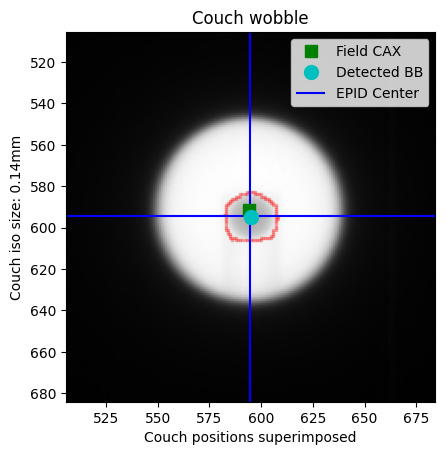

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
wl.plot_axis_images(axis=Axis.GANTRY)
wl.plot_axis_images(axis=Axis.COLLIMATOR)
wl.plot_axis_images(axis=Axis.COUCH)

### 7d. 3D isocenter visualization

An interactive-style 3D plot of the BB, radiation isocenter sphere, and per-axis isocenters.

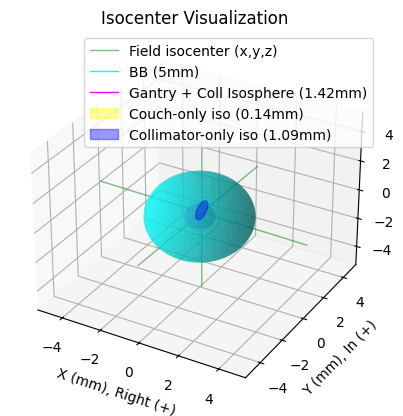

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

In [19]:
wl.plot_location()

### 7e. Big summary figure

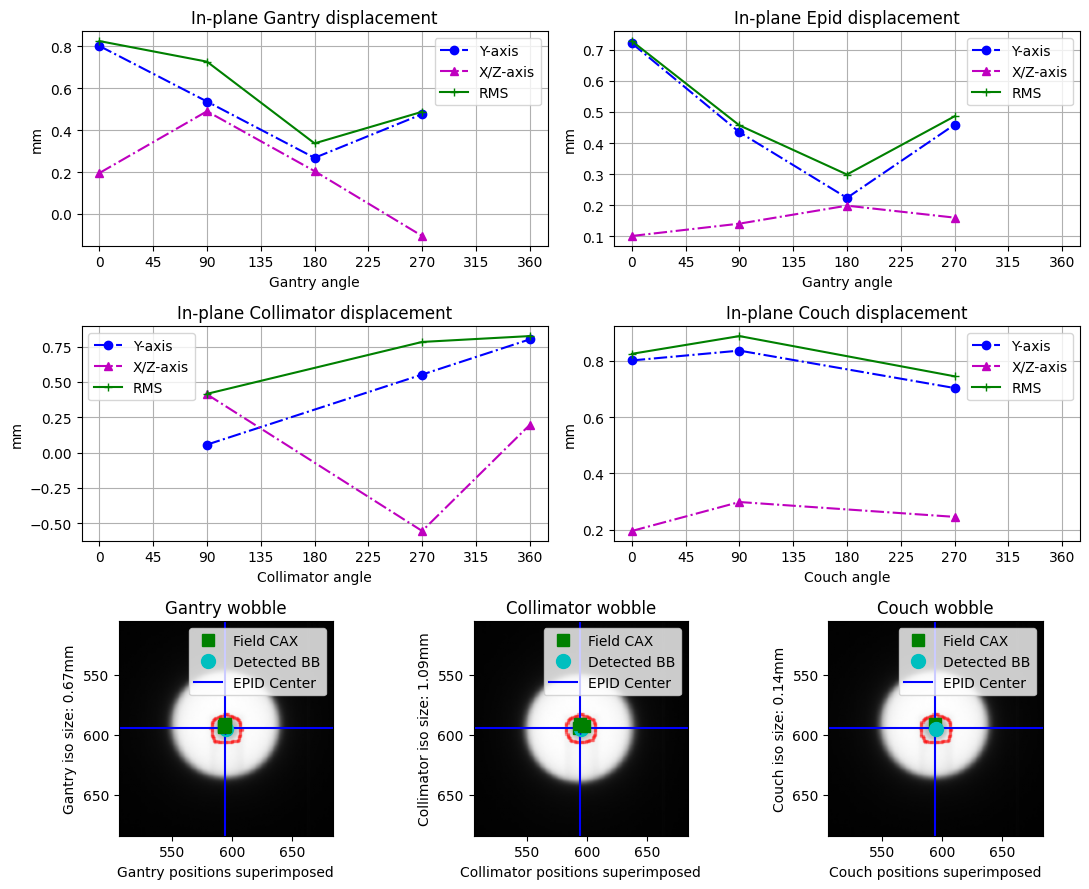

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [20]:
wl.plot_summary()

### 7f. (Optional) Publish a full PDF report

In [21]:
wl.publish_pdf("WL_report.pdf")
print("Saved WL_report.pdf")

Saved WL_report.pdf


## 8. Pylinac summary

In [22]:
print(wl.results())

Winston-Lutz Analysis
Number of images: 14
Maximum 2D CAX->BB distance: 0.90mm
Median 2D CAX->BB distance: 0.67mm
Mean 2D CAX->BB distance: 0.62mm
Shift to iso: facing gantry, move BB: RIGHT 0.02mm; IN 0.17mm; UP 0.31mm
Gantry 3D isocenter diameter: 0.67mm (4/14 images considered)
Maximum Gantry RMS deviation (mm): 0.82mm
Maximum EPID RMS deviation (mm): 0.79mm
Gantry+Collimator 3D isocenter diameter: 1.42mm (12/14 images considered)
Collimator 2D isocenter diameter: 1.09mm (3/14 images considered)
Maximum Collimator RMS deviation (mm): 0.82
Couch 2D isocenter diameter: 0.14mm (3/14 images considered)
Maximum Couch RMS deviation (mm): 0.89
